In this section, we import all the necessary libraries for image processing, data handling, and model training. We also check the Ultralytics YOLO version and set a random seed for reproducibility.

In [1]:
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.2 MB/s eta 0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.3.131
    Uninstalling ultralytics-8.3.131:
      Successfully uninstalled ultralytics-8.3.131

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch
import ultralytics
import random
from torchvision import transforms
from sklearn.metrics import confusion_matrix, mean_absolute_error, r2_score
import numpy as np
from tqdm import tqdm
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Check Ultralytics version
print(f"Ultralytics version: {ultralytics.__version__}")
if ultralytics.__version__ < '8.3.146':
    print("Warning: Ultralytics version is outdated. Please update with 'pip install -U ultralytics'")

# Set random seed for reproducibility
random.seed(42)

Ultralytics version: 8.3.146


### Define YOLO Annotation Function

This function converts the dataset annotations from COCO format to YOLO format for a given data split (train/val/test). It creates YOLO annotation `.txt` files and copies the corresponding images to the output directory.

In [2]:
def create_yolo_annotations(root_dir, output_dir, partition='train'):
    """
    Convert annotations.json to YOLO format for a given partition (train/val/test).
    Creates .txt files with class_id and normalized bbox coordinates.
    Returns list of image paths for the partition.
    """
    # Load annotations
    anns_file = os.path.join(root_dir, 'annotations.json')
    if not os.path.exists(anns_file):
        print(f"Error: Annotations file {anns_file} not found")
        return [], {}
    anns = json.load(open(anns_file))
    categories = {c['id']: c['name'] for c in anns['categories']}
    image_info = {img['id']: img for img in anns['images']}

    # Check if partition exists
    if partition not in anns['splits']['chessred2k']:
        print(f"Error: Partition '{partition}' not found in annotations.json")
        return [], categories

    # Get split IDs
    split_ids = np.asarray(anns['splits']['chessred2k'][partition]['image_ids']).astype(int)
    image_ids = [img['id'] for img in anns['images'] if img['id'] in split_ids]
    image_paths = []
    images_processed = 0
    images_skipped = 0

    # Create output directory for labels
    label_dir = os.path.join(output_dir, partition, 'labels')
    image_dir = os.path.join(output_dir, partition, 'images')
    os.makedirs(label_dir, exist_ok=True)
    os.makedirs(image_dir, exist_ok=True)

    for image_id in image_ids:
        img_info = image_info[image_id]
        file_name = img_info['path']
        img_path = os.path.join(root_dir, file_name)
        if not os.path.exists(img_path):
            print(f"Warning: Image not found at {img_path}")
            images_skipped += 1
            continue
        width, height = img_info['width'], img_info['height']

        # Copy image to output directory
        output_img_path = os.path.join(image_dir, os.path.basename(file_name))
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not load image {img_path}")
            images_skipped += 1
            continue
        cv2.imwrite(output_img_path, img)
        image_paths.append(os.path.join(partition, 'images', os.path.basename(file_name)))
        images_processed += 1

        # Create YOLO annotation file
        label_path = os.path.join(label_dir, os.path.splitext(os.path.basename(file_name))[0] + '.txt')
        with open(label_path, 'w') as f:
            for piece in anns['annotations']['pieces']:
                if piece['image_id'] == image_id and 'bbox' in piece:
                    x, y, w, h = piece['bbox']
                    class_id = piece['category_id']
                    # Normalize coordinates: center_x, center_y, width, height
                    center_x = (x + w / 2) / width
                    center_y = (y + h / 2) / height
                    norm_w = w / width
                    norm_h = h / height
                    # Ensure coordinates are within [0, 1]
                    if 0 <= center_x <= 1 and 0 <= center_y <= 1 and norm_w > 0 and norm_h > 0:
                        f.write(f"{class_id} {center_x:.6f} {center_y:.6f} {norm_w:.6f} {norm_h:.6f}\n")
                    else:
                        print(f"Warning: Invalid bbox for image_id {image_id}: {piece['bbox']}")

    print(f"Processed {images_processed} images for {partition} split, skipped {images_skipped}")
    return image_paths, categories

### Setup dataset

Convert the dataset annotations to YOLO format, creates the necessary directory structure

In [5]:
root_dir = ''  # Update with your dataset path
output_dir = '/Volumes/KINGSTON/Projects/vcom_proj2/yolo_chess_dataset'  # Output directory for YOLO format
model_name = 'yolo11n.pt'  # Pretrained YOLOv11 model
img_size = 640  # Training image size
epochs = 50  # Number of training epochs
batch_size = 16  # Batch size (adjust based on GPU memory)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Create YOLO annotations
print("Converting annotations for training set...")
train_paths, categories = create_yolo_annotations(root_dir, output_dir, 'train')
print("Converting annotations for validation set...")
val_paths, _ = create_yolo_annotations(root_dir, output_dir, 'val')
print("Converting annotations for test set...")
test_paths, _ = create_yolo_annotations(root_dir, output_dir, 'test')

Converting annotations for training set...
Processed 1442 images for train split, skipped 0
Converting annotations for validation set...
Processed 330 images for val split, skipped 0
Converting annotations for test set...
Processed 306 images for test split, skipped 0


Piece count: 18


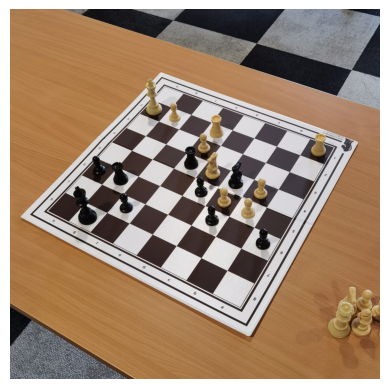

In [16]:
def load_true_piece_counts(root_dir, partition='test'):
    anns = json.load(open(os.path.join(root_dir, 'annotations.json')))
    image_id_to_count = {}

    split_ids = anns['splits']['chessred2k'][partition]['image_ids']
    split_ids = set(split_ids)

    for img in anns['images']:
        if img['id'] in split_ids:
            image_id_to_count[img['id']] = 0

    for piece in anns['annotations']['pieces']:
        img_id = piece['image_id']
        if img_id in image_id_to_count:
            image_id_to_count[img_id] += 1

    image_id_to_filename = {
        img['id']: os.path.join(root_dir, img['path'])
        for img in anns['images'] if img['id'] in image_id_to_count
    }

    filenames = list(image_id_to_filename.values())
    counts = [image_id_to_count[img_id] for img_id in image_id_to_filename]

    return filenames, counts

# Load example
test_paths, true_counts = load_true_piece_counts(root_dir, partition='test')
random_number = random.randint(0, len(test_paths) - 1)
image = cv2.imread(test_paths[random_number], cv2.IMREAD_COLOR_RGB)

plt.imshow(image)
print("Piece count:", int(true_counts[random_number]))
plt.axis('off')
plt.show()

### Run Inference on Test Image

Here, we use the trained YOLO model to run inference on several test images. The results are visualized side-by-side with the original images, and the annotated images are saved for inspection. This step demonstrates the model's performance on unseen data.

In [29]:
def evaluate_yolo_on_piece_count(image_paths, true_counts, model, conf_threshold=0.7):
    predicted_counts = []

    for image_path in tqdm(image_paths, desc="Running YOLO inference"):
        results = model.predict(image_path, save=False, conf=conf_threshold, verbose=False)
        pred_count = sum(len(r.boxes) for r in results)
        predicted_counts.append(pred_count)

    predicted_counts = np.array(predicted_counts)
    true_counts = np.array(true_counts, dtype=float)

    # Metrics
    preds_rounded = np.round(predicted_counts).astype(int)
    preds_rounded = np.clip(preds_rounded, 0, 32)
    true_counts_int = true_counts.astype(int)

    mae = mean_absolute_error(true_counts, predicted_counts)
    acc = np.mean(preds_rounded == true_counts_int)
    cm = confusion_matrix(true_counts_int, preds_rounded, labels=np.arange(33))

    return mae, acc, cm

In [32]:
root_dir = ''  # Update with your dataset path
output_dir = '/Volumes/KINGSTON/Projects/vcom_proj2/yolo_chess_dataset'
model_path = 'runs/detect/chess_piece_detection/weights/best.pt'
conf_threshold = 0.8

model = YOLO(model_path)

# Run evaluation
mae, acc, cm = evaluate_yolo_on_piece_count(test_paths, true_counts, model, conf_threshold)

Running YOLO inference: 100%|██████████| 306/306 [00:35<00:00,  8.52it/s]



Test results:
MAE: 0.252
Exact Count Accuracy: 0.843


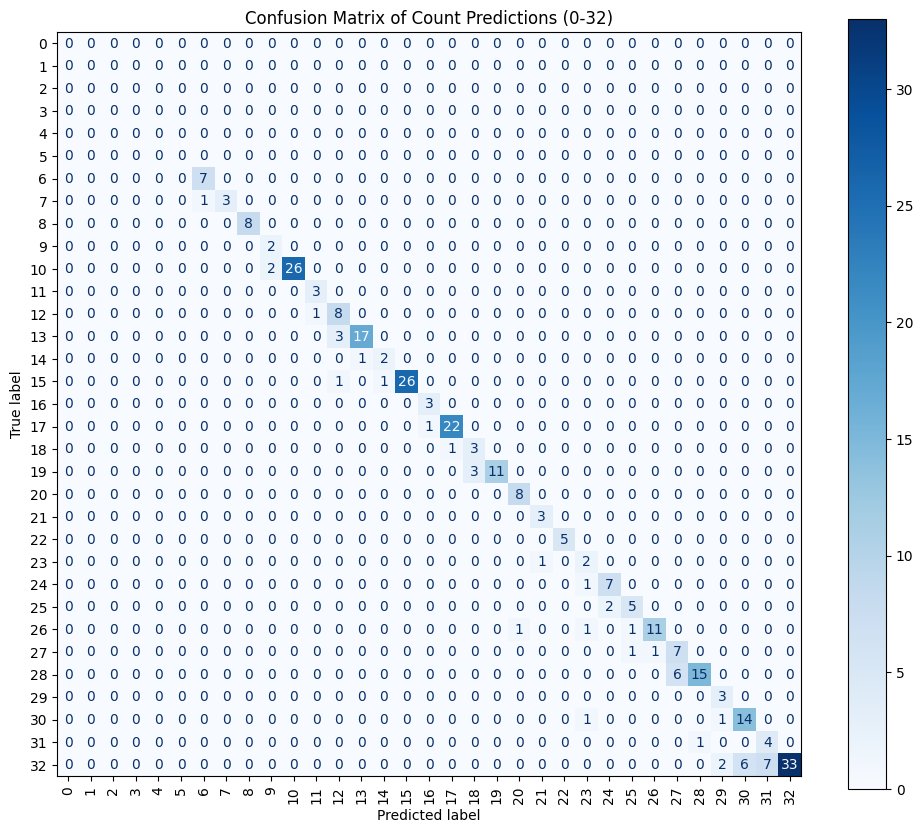

In [33]:

# Print results
print("\nTest results:")
print(f"MAE: {mae:.3f}")
print(f"Exact Count Accuracy: {acc:.3f}")

max_piece_count = np.arange(33)
#confusion matrix visualization with numbers
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=max_piece_count)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix of Count Predictions (0-32)")
plt.show()